# Assignment 3
### Due 9/23. Do four of five.

1.
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('nhanes_data_17_18.csv')
df.head(20)




/tmp/ipython-input-1551632306.py:6: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('nhanes_data_17_18.csv')


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,93708.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,60.0,118.0,0.0,Never
6,93709.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.0,5.0,0.0,NaN,NaN,NaN,62.0,200.0,0.0,6 to 10
7,93711.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,69.0,142.0,0.0,Never
8,93712.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,2.0,1.0,10.0,4.0,Months,68.0,135.0,0.0,Never
9,93713.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.0,15.0,1.0,3.0,1.0,Days,70.0,165.0,0.0,Never


In [4]:
null_counts = df[['GeneralHealthCondition', 'TypeOfMilkFirstFedWholeMilk']].isna().sum()

print(null_counts)

GeneralHealthCondition         2402
TypeOfMilkFirstFedWholeMilk    7628
dtype: int64


The two categorical variables I selected are generalhealthcondition and typeoffirstfedwholemilk. Both of these variables have multiple null values, with some responses having a null for one of these two variables and a value for the other. It seems like General Health Condition has 1/3rd of the null values that Type Of Milk First Fed Whole Milk does. This likely comes down to some part of their surveying method making it more likely to record a response for general health condition.

In [5]:
contingency_table = pd.crosstab(
    df['GeneralHealthCondition'],
    df['TypeOfMilkFirstFedWholeMilk'],
    dropna=False
)

print(contingency_table)

TypeOfMilkFirstFedWholeMilk  Whole or regular milk   NaN
GeneralHealthCondition                                  
Excellent                                        0   619
Fair or                                          0  1175
Good                                             0  2454
Poor?                                            0   172
Very good                                        0  1544
NaN                                            738  1664


While this table provides very little useful information since there are so many nulls and the variables have different possible responses, it appears that when general health condition is null, milk is more likely to be null. While this does not reveal anything specifically about the data, it can provide insights into the survey methods and potentially on the validity of using this data for statistical analysis.

2.
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [6]:
import pandas as pd
import numpy as np


df=pd.read_csv('nhanes_data_17_18.csv')
df.head(5)


/tmp/ipython-input-3041368267.py:5: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('nhanes_data_17_18.csv')


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The categorical variable selected is again general health condition, as this provides a good overall measure of health. The numeric variable selected is age first fed formula days. With these variables, we can see if general health and starting formula are connected.

In [7]:

null_counts = df[['GeneralHealthCondition', 'AgeFirstFedFormuladays']].isna().sum()

print(null_counts)

GeneralHealthCondition    2402
AgeFirstFedFormuladays    7289
dtype: int64


The null values are similar to the previous question, with GeneralHealthCondition being null about 1/3 of the amount that AgeFirstFed is. This can be interpreted as the general health question being prioritized or asked to more patients during surveying, or due to many parents not using formula, so there is a null value.

In [8]:
#AI Assisted code
import numpy as np
import matplotlib.pyplot as plt
# --- Columns
y_col = "AgeFirstFedFormuladays"       # numeric Y
x_col = "GeneralHealthCondition"       # categorical X

# --- Coerce types and drop rows without overlap ---
# Make sure Y is numeric
df[y_col] = pd.to_numeric(df[y_col], errors="coerce")

# Keep only rows where both Y and X are present
sub = df[[y_col, x_col]].dropna(subset=[y_col, x_col]).copy()

# If no overlapping rows, stop early with a helpful message
if sub.empty:
    print("No overlapping non-missing rows for AgeFirstFedFormuladays and GeneralHealthCondition.")
else:
    # Ensure X is a categorical dtype (helps with ordered summaries/plots)
    sub[x_col] = sub[x_col].astype("category")

    # ---- Descriptive tables ----
    # 1) Standard describe() per group
    desc = sub.groupby(x_col)[y_col].describe()

    # 2) Extra stats (median, IQR, MAD) per group
    def iqr(s):
        return np.nanpercentile(s, 75) - np.nanpercentile(s, 25)

    extra = sub.groupby(x_col)[y_col].agg(
        n_non_missing="count",
        median="median",
        iqr=iqr,
        mad=lambda s: np.nanmedian(np.abs(s - np.nanmedian(s)))
    )

    # Merge the two tables (optional; you can print separately if you prefer)
    descriptive_table = desc.join(extra)

    print("\n=== Descriptive Statistics by GeneralHealthCondition ===")
    print(descriptive_table)

    # ---- Grouped Kernel Density Plots ----
    # Overlay KDE: one figure with all categories
    plt.figure(figsize=(10, 6))
    # Loop each category and plot its KDE
    categories = sub[x_col].cat.categories
    for cat in categories:
        vals = sub.loc[sub[x_col] == cat, y_col].dropna()
        if len(vals) > 1:
            vals.plot(kind="kde", label=str(cat))  # uses matplotlib under the hood
    plt.title("Kernel Density of AgeFirstFedFormuladays by GeneralHealthCondition")
    plt.xlabel("Age First Fed Formula (days)")
    plt.ylabel("Density")
    plt.legend(title=x_col, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Small multiples (one panel per category)
    n = len(categories)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows), squeeze=False)
    axes = axes.ravel()

    for i, cat in enumerate(categories):
        ax = axes[i]
        vals = sub.loc[sub[x_col] == cat, y_col].dropna()
        if len(vals) > 1:
            vals.plot(kind="kde", ax=ax)
            ax.set_title(f"{x_col}: {cat}")
            ax.set_xlabel("Age First Fed Formula (days)")
            ax.set_ylabel("Density")
        else:
            ax.text(0.5, 0.5, "Not enough data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()

    # Hide any extra axes if categories don’t fill the grid
    for j in range(i + 1, len(axes)):
        axes[j].set_axis_off()

    plt.tight_layout()
    plt.show()

No overlapping non-missing rows for AgeFirstFedFormuladays and GeneralHealthCondition.


Interestingly, there are no rows where both variables have non null values, meaning it is useless for creating descriptive tables or grouped kernel density plots. This is a real problem for the dataset, as there is clear correlation between the null values since there is no overlap. The likely means that this dataset was compiled by grouping somewhat related surveys together and treating it as one dataset.

3.
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

4.
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

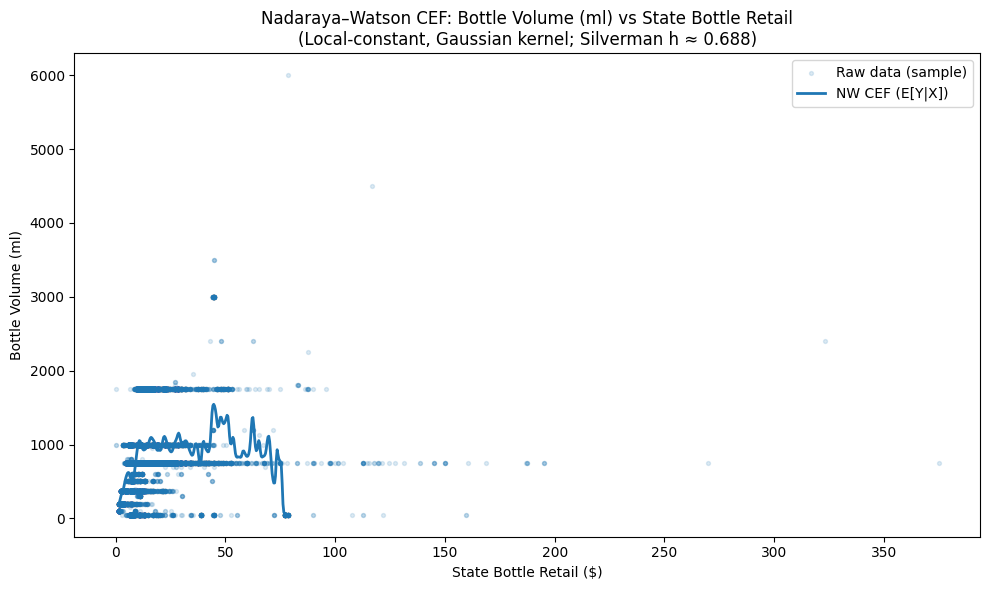

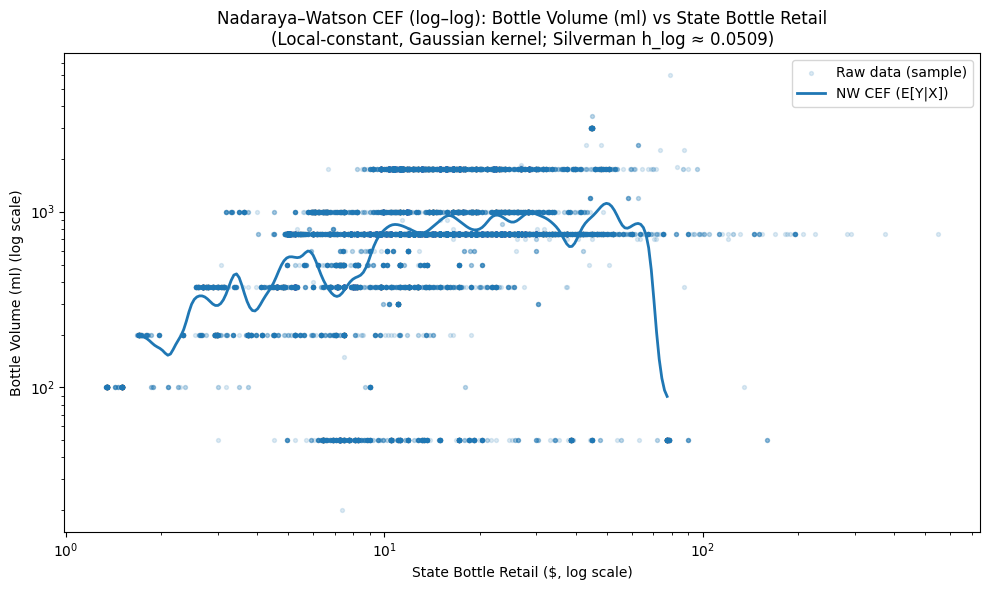

In [20]:
# AI Assisted Code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Core Estimator ----------

class NadarayaWatson:
    """
    Local-constant (Nadaraya–Watson) regression with Gaussian kernel.
    Bandwidth options:
      - 'silverman' (default): 0.9 * min(sd, IQR/1.34) * n^(-1/5)
      - float value: use that as bandwidth
    """
    def __init__(self, bandwidth='silverman', kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel
        self.x_ = None
        self.y_ = None
        self.h_ = None

    @staticmethod
    def _gaussian_kernel(u):
        return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)

    @staticmethod
    def _silverman_bandwidth(x):
        x = np.asarray(x, dtype=float)
        x = x[~np.isnan(x)]
        n = x.size
        if n < 2:
            return np.nan
        sd = np.std(x, ddof=1)
        iqr = np.subtract(*np.percentile(x, [75, 25]))
        # Silverman scale: use the smaller of sd and IQR/1.34 (if both > 0)
        if (sd > 0) and (iqr > 0):
            scale = min(sd, iqr / 1.34)
        else:
            # fall back to a nonzero scale if one is zero
            scale = max(sd, iqr / 1.34)
        return 0.9 * scale * (n ** (-1/5))

    def fit(self, x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        mask = ~(np.isnan(x) | np.isnan(y))
        self.x_ = x[mask]
        self.y_ = y[mask]
        if isinstance(self.bandwidth, str) and self.bandwidth.lower() == 'silverman':
            self.h_ = self._silverman_bandwidth(self.x_)
        else:
            self.h_ = float(self.bandwidth)
        return self

    def predict(self, x_new):
        if self.x_ is None:
            raise RuntimeError("Call fit() before predict().")

        x_new = np.asarray(x_new, dtype=float)
        h = self.h_
        if not np.isfinite(h) or h <= 0:
            return np.full_like(x_new, np.nan, dtype=float)

        # weights: K((x_i - x0)/h) for each x0
        diffs = (self.x_[None, :] - x_new[:, None]) / h
        if self.kernel == 'gaussian':
            w = self._gaussian_kernel(diffs)
        else:
            raise NotImplementedError("Only Gaussian kernel is implemented.")

        wsum = w.sum(axis=1)
        yhat = np.where(wsum > 0, (w @ self.y_) / wsum, np.nan)
        return yhat


# ---------- Convenience helpers for CEF plotting ----------

def cef_curve(x, y, x_grid=None, bandwidth='silverman'):
    """
    Fit NW and return CEF over x_grid.
    """
    nw = NadarayaWatson(bandwidth=bandwidth).fit(x, y)
    if x_grid is None:
        x_grid = np.linspace(np.nanpercentile(x, 1), np.nanpercentile(x, 99), 200)
    cef = nw.predict(x_grid)
    return x_grid, cef, nw.h_

def plot_cef_with_scatter(x, y, x_grid, cef, title, xlab, ylab,
                          scatter_sample=20000, logx=False, logy=False):
    """
    Scatter (optionally subsampled) + CEF line.
    """
    rng = np.random.default_rng(0)
    idx = np.arange(len(x))
    if len(idx) > scatter_sample:
        idx = rng.choice(idx, size=scatter_sample, replace=False)

    plt.figure(figsize=(10, 6))
    plt.scatter(x[idx], y[idx], alpha=0.15, s=8, label="Raw data (sample)")
    plt.plot(x_grid, cef, linewidth=2, label="NW CEF (E[Y|X])")
    if logx:
        plt.xscale("log")
    if logy:
        plt.yscale("log")
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------- Example: Iowa dataset ----------

if __name__ == "__main__":
    # Load your CSV (adjust path if necessary)
    df = pd.read_csv("iowa.csv", low_memory=False)

    # Select variables
    xcol = "State Bottle Retail"
    ycol = "Bottle Volume (ml)"

    # Ensure numeric & drop missing
    df[xcol] = pd.to_numeric(df[xcol], errors="coerce")
    df[ycol] = pd.to_numeric(df[ycol], errors="coerce")
    dat = df[[xcol, ycol]].dropna()
    X = dat[xcol].to_numpy()
    Y = dat[ycol].to_numpy()

    # ---- (A) Original scale CEF ----
    xg, cef, h = cef_curve(X, Y, bandwidth="silverman")
    plot_cef_with_scatter(
        X, Y, xg, cef,
        title=f"Nadaraya–Watson CEF: {ycol} vs {xcol}\n(Local-constant, Gaussian kernel; Silverman h ≈ {h:.3g})",
        xlab=f"{xcol} ($)",
        ylab=ycol,
        scatter_sample=20000,  # reduce if plotting is slow
        logx=False, logy=False
    )

    # ---- (B) Log–log CEF (handles heavy tails better) ----
    mask_pos = (X > 0) & (Y > 0)
    Xp, Yp = X[mask_pos], Y[mask_pos]
    Xlog, Ylog = np.log(Xp), np.log(Yp)

    xg_log, cef_log, h_log = cef_curve(Xlog, Ylog, bandwidth="silverman")
    # Back-transform the CEF for plotting on original units
    xg_bt = np.exp(xg_log)
    cef_bt = np.exp(cef_log)

    plot_cef_with_scatter(
        Xp, Yp, xg_bt, cef_bt,
        title=f"Nadaraya–Watson CEF (log–log): {ycol} vs {xcol}\n(Local-constant, Gaussian kernel; Silverman h_log ≈ {h_log:.3g})",
        xlab=f"{xcol} ($, log scale)",
        ylab=f"{ycol} (log scale)",
        scatter_sample=20000,
        logx=True, logy=True
    )


Based on the plots, it appears that the relationship is positive at lower price levels, but as bottles get more expensive we see a drop in their volume. Conceptually this makes sense as lower quality liquors will be higher priced in bigger bottles, but often the extremely expenive bottles are smaller.

5.
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

In [9]:
df = pd.read_csv('iowa.csv')
df.head()

,Invoice/Item Number,Date,Store Number,Store Name,Zip Code,Category Name,Vendor Name,Item Number,Item Description,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars)
0,INV-59108400026,06/06/2023,3723,J D SPIRITS LIQUOR,51040,STRAIGHT RYE WHISKIES,INFINIUM SPIRITS,27102,TEMPLETON RYE 4YR,750,18.09,27.14,2,54.28
1,S16879800057,01/16/2014,3926,LIQUOR DOWNTOWN / IOWA CITY,52240,VODKA 80 PROOF,HEAVEN HILL BRANDS,35416,BURNETT'S VODKA 80 PRF,750,4.84,7.26,12,87.12
2,INV-05301100019,06/05/2017,3829,GARY'S FOODS / MT VERNON,52314,CANADIAN WHISKIES,DIAGEO AMERICAS,11296,CROWN ROYAL,750,15.59,23.39,6,135.66
3,INV-40973500083,10/14/2021,5102,WILKIE LIQUORS,52314,AMERICAN SCHNAPPS,JIM BEAM BRANDS,82787,DEKUYPER BUTTERSHOTS,1000,7.87,11.81,12,141.72
4,INV-17022500013,01/18/2019,2560,HY-VEE FOOD STORE / MARION,52302,WHISKEY LIQUEUR,SAZERAC COMPANY INC,64863,FIREBALL CINNAMON WHISKEY,200,2.50,3.75,12,45.00


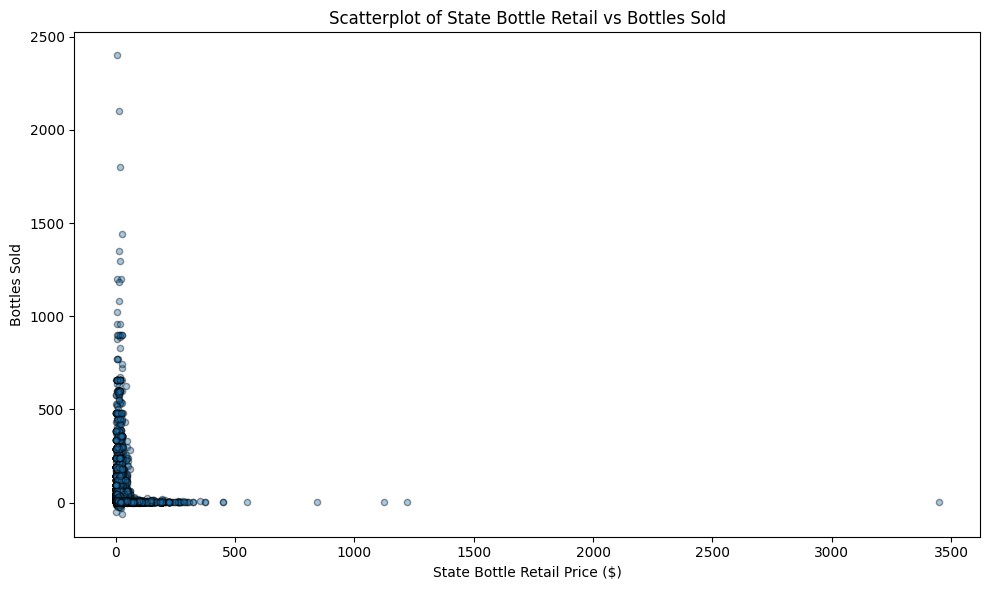

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(df['State Bottle Retail'], df['Bottles Sold'],
            alpha=0.4, s=20, edgecolor='k')

plt.title("Scatterplot of State Bottle Retail vs Bottles Sold")
plt.xlabel("State Bottle Retail Price ($)")
plt.ylabel("Bottles Sold")
plt.tight_layout()
plt.show()

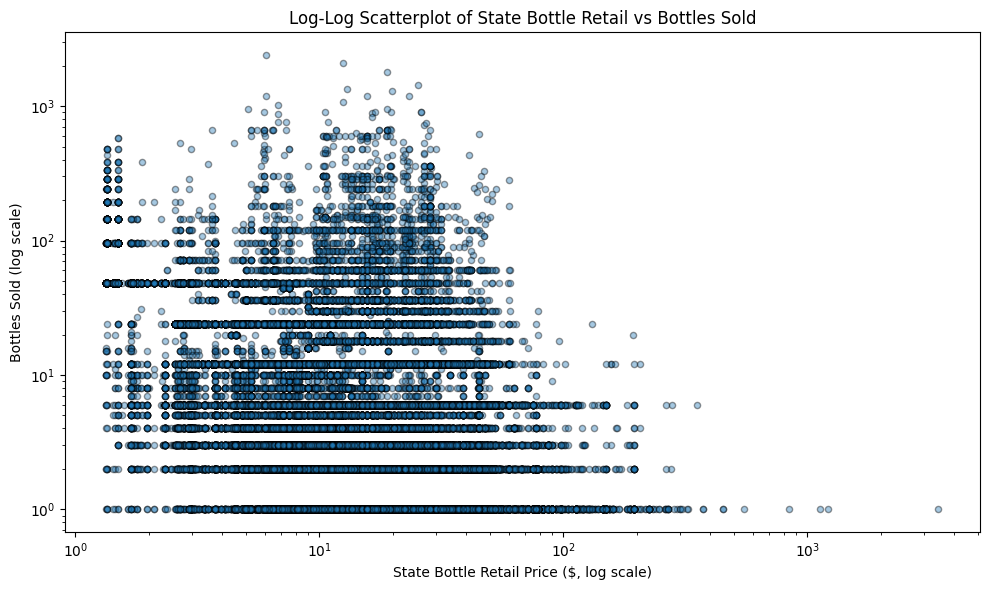

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(df['State Bottle Retail'], df['Bottles Sold'],
            alpha=0.4, s=20, edgecolor='k')

plt.xscale("log")
plt.yscale("log")

plt.title("Log-Log Scatterplot of State Bottle Retail vs Bottles Sold")
plt.xlabel("State Bottle Retail Price ($, log scale)")
plt.ylabel("Bottles Sold (log scale)")
plt.tight_layout()
plt.show()

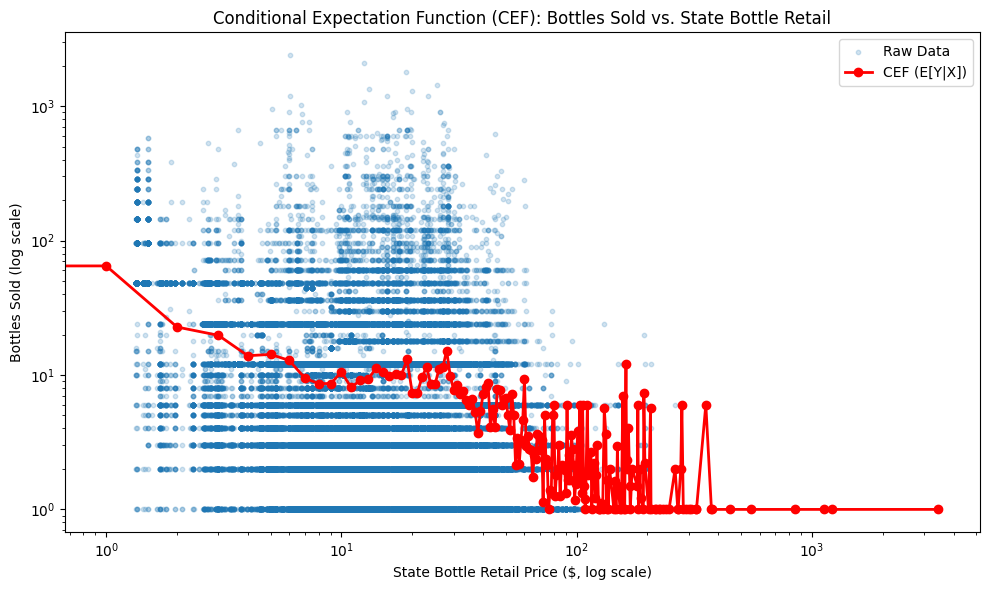

In [18]:
bin_size = 1
df['PriceBin'] = (df['State Bottle Retail'] // bin_size) * bin_size


cef = (
    df.groupby('PriceBin')['Bottles Sold']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
plt.scatter(df['State Bottle Retail'], df['Bottles Sold'],
            alpha=0.2, s=10, label="Raw Data")


plt.plot(cef['PriceBin'], cef['Bottles Sold'],
         color='red', marker='o', linewidth=2, label="CEF (E[Y|X])")

plt.xscale("log")
plt.yscale("log")

plt.title("Conditional Expectation Function (CEF): Bottles Sold vs. State Bottle Retail")
plt.xlabel("State Bottle Retail Price ($, log scale)")
plt.ylabel("Bottles Sold (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

Given that the relationship between supply and demand is causal, the relationship between the price of a bottle and its sales volume is causal. We see this relationship in both the larger scatterplot, as well as more defined in the log scaled plot. Another more basic way to interpret the relationship is that very few people can afford the expensive bottles, so they naturally have a lower quantity sold.

Despite the causal effect, there is still variance within the dataset and our model can be used to predict what the sales volume will be of a new product based on price. If intervention occurs, such as the government forcing certain products to price above or below what they should, then our model will not be valid for prediction.